In [1]:
# Import required libraries (CUDA version)
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import machine learning libraries
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, confusion_matrix



In [15]:
# Load the dataset into a pandas DataFrame
df = pd.read_csv('../Sino_CT.csv')

# Convert the 'embedding' column from string to a list
df['embedding'] = df['embedding'].apply(eval)

# Map the 'label' column to 0 for abnormal ('0,1') and 1 for normal ('1,0')
df['label'] = df['label'].apply(lambda x: 1 if x == '1,0' else 0)

# Define the target column
target_column = 'label'

# Load the embeddings and target values
X = np.array(df['embedding'].tolist(), dtype=np.float32)
y = df[target_column].values.astype(np.float32)

# Reshape y to be (n_samples, 1) for consistency with the model output
y = y.reshape(-1, 1)

# Define the different train sizes to test (from small to large)
train_sizes = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60]
split_results = []

def create_split(train_size):
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=train_size, random_state=42)
    
    # Scale the features using StandardScaler
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Convert to PyTorch tensors
    X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32)
    
    # Calculate appropriate batch size (minimum 4, maximum 32)
    batch_size = min(32, max(4, X_train_tensor.shape[0] // 10))
    
    # Create TensorDatasets and DataLoaders
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
    
    # Drop last incomplete batch during training to avoid batch norm issues
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)
    
    return train_loader, test_loader, X_train_tensor.shape[0], X_test_tensor.shape[0], batch_size

In [16]:
import torch
import torch.nn as nn

class TensorFlowToPyTorchModel(nn.Module):
    def __init__(self, input_features=1408):
        super(TensorFlowToPyTorchModel, self).__init__()
        
        # Define the sequential layers
        self.model = nn.Sequential(
            # First block: 1408 → 1536
            nn.Linear(input_features, 1536),
            nn.BatchNorm1d(1536),
            nn.ReLU(),
            nn.Dropout(p=0.4372695307748339),
            
            # Second block: 1536 → 896
            nn.Linear(1536, 896),
            nn.BatchNorm1d(896),
            nn.ReLU(),
            nn.Dropout(p=0.3417774049274107),
            
            # Third block: 896 → 128
            nn.Linear(896, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(p=0.24257773824341827),
            
            # Output layer: 128 → 1 (no activation, BN, or dropout)
            nn.Linear(128, 1)
        )
    
    def forward(self, x):
        return self.model(x)

# Instantiate the model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = TensorFlowToPyTorchModel(input_features=1408)
model = model.to(device)

In [17]:
# Training function
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        # Move data to device
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward pass and optimize
        loss.backward()
        optimizer.step()
        
        # Track metrics
        running_loss += loss.item() * inputs.size(0)
        predictions = torch.sigmoid(outputs) > 0.5
        correct += (predictions == labels).sum().item()
        total += labels.size(0)
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

# Validation function
def validate_epoch(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            probs = torch.sigmoid(outputs)
            predictions = probs > 0.5
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
            
            # Store for AUC calculation
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    epoch_auc = roc_auc_score(all_labels, all_probs)
    
    return epoch_loss, epoch_acc, epoch_auc, all_labels, all_probs

In [18]:
# Define loss function and optimizer
criterion = nn.BCEWithLogitsLoss()

def train_model(train_loader, test_loader, train_size):
    # Initialize model
    model = TensorFlowToPyTorchModel(input_features=1408).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    
    best_val_auc = 0.0
    best_model_weights = None
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    val_aucs = []
    
    # Adjust number of epochs based on training size
    adjusted_epochs = min(100, max(50, int(100 * (1 / train_size))))
    
    print(f"\nTraining with {train_size:.1%} training data...")
    print(f"Number of epochs: {adjusted_epochs}")
    
    for epoch in range(adjusted_epochs):
        # Train
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Validate
        val_loss, val_acc, val_auc, _, _ = validate_epoch(model, test_loader, criterion, device)
        
        # Store metrics
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        val_aucs.append(val_auc)
        
        # Learning rate scheduling
        scheduler.step(val_loss)
        
        # Save best model
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_model_weights = model.state_dict().copy()
        
        # Print progress every 10 epochs
        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{adjusted_epochs}] "
                  f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val AUC: {val_auc:.4f}")
    
    # Load best model
    model.load_state_dict(best_model_weights)
    
    # Final evaluation
    test_loss, test_acc, test_auc, test_labels, test_probs = validate_epoch(
        model, test_loader, criterion, device
    )
    
    # Calculate additional metrics
    test_preds = (np.array(test_probs) > 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(test_labels, test_preds).ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    f1 = 2 * tp / (2 * tp + fp + fn)
    
    return {
        'train_size': train_size,
        'best_auc': best_val_auc,
        'final_metrics': {
            'loss': test_loss,
            'accuracy': test_acc,
            'auc': test_auc,
            'sensitivity': sensitivity,
            'specificity': specificity,
            'f1_score': f1
        },
        'training_history': {
            'train_losses': train_losses,
            'val_losses': val_losses,
            'train_accs': train_accs,
            'val_accs': val_accs,
            'val_aucs': val_aucs
        },
        'confusion_matrix': {'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp}
    }

# Run experiments for different splits
all_results = []
for train_size in train_sizes:
    # Create data loaders for this split
    train_loader, test_loader, n_train, n_test, batch_size = create_split(train_size)
    print(f"\nSplit {train_size:.1%} train / {1-train_size:.1%} test")
    print(f"Training samples: {n_train}, Test samples: {n_test}")
    print(f"Batch size: {batch_size}")
    
    # Train and evaluate model
    results = train_model(train_loader, test_loader, train_size)
    all_results.append(results)
    
    print(f"\nResults for {train_size:.1%} training data:")
    print(f"Best AUC: {results['best_auc']:.4f}")
    print(f"Final metrics:")
    for metric, value in results['final_metrics'].items():
        print(f"{metric}: {value:.4f}")


Split 5.0% train / 95.0% test
Training samples: 341, Test samples: 6489
Batch size: 32

Training with 5.0% training data...
Number of epochs: 100
Epoch [10/100] Train Loss: 0.2395, Train Acc: 0.8781 | Val Loss: 0.6554, Val Acc: 0.7174, Val AUC: 0.7941
Epoch [10/100] Train Loss: 0.2395, Train Acc: 0.8781 | Val Loss: 0.6554, Val Acc: 0.7174, Val AUC: 0.7941
Epoch [20/100] Train Loss: 0.1303, Train Acc: 0.9531 | Val Loss: 0.7825, Val Acc: 0.7217, Val AUC: 0.7853
Epoch [20/100] Train Loss: 0.1303, Train Acc: 0.9531 | Val Loss: 0.7825, Val Acc: 0.7217, Val AUC: 0.7853
Epoch [30/100] Train Loss: 0.0848, Train Acc: 0.9781 | Val Loss: 0.8465, Val Acc: 0.7146, Val AUC: 0.7811
Epoch [30/100] Train Loss: 0.0848, Train Acc: 0.9781 | Val Loss: 0.8465, Val Acc: 0.7146, Val AUC: 0.7811
Epoch [40/100] Train Loss: 0.0944, Train Acc: 0.9750 | Val Loss: 0.8750, Val Acc: 0.7124, Val AUC: 0.7770
Epoch [40/100] Train Loss: 0.0944, Train Acc: 0.9750 | Val Loss: 0.8750, Val Acc: 0.7124, Val AUC: 0.7770
Epoch

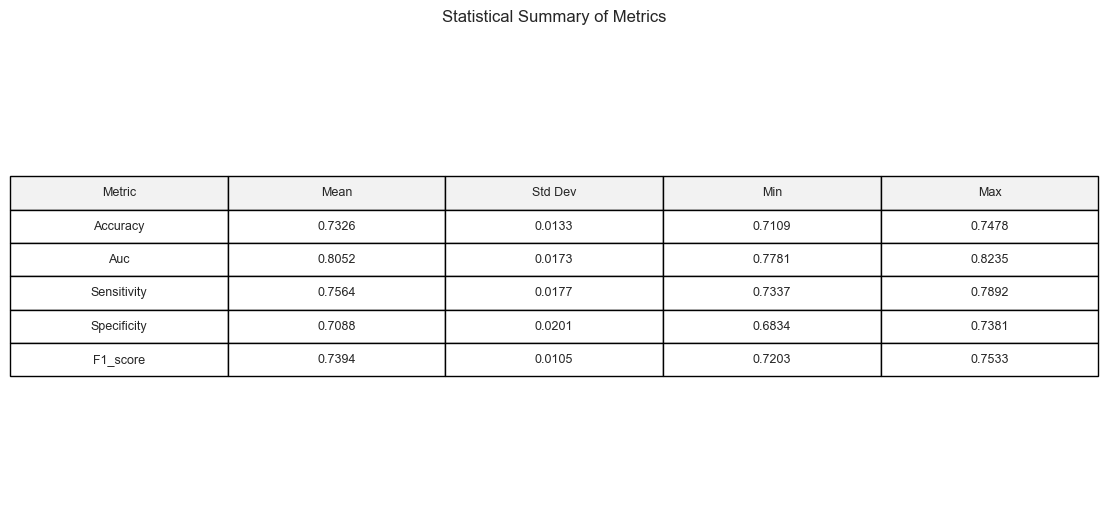


Detailed Results Table:
Train Size  accuracy    auc  sensitivity  specificity  f1_score
      5.0%    0.7109 0.7781       0.7337       0.6874    0.7203
     10.0%    0.7199 0.7832       0.7466       0.6923    0.7304
     20.0%    0.7257 0.7993       0.7669       0.6834    0.7390
     30.0%    0.7342 0.8110       0.7435       0.7247    0.7384
     40.0%    0.7426 0.8206       0.7470       0.7381    0.7442
     50.0%    0.7473 0.8207       0.7678       0.7273    0.7502
     60.0%    0.7478 0.8235       0.7892       0.7084    0.7533

Key Findings:
Best Accuracy: 0.7478 (at 60.0% training size)
Best Auc: 0.8235 (at 60.0% training size)
Best Sensitivity: 0.7892 (at 60.0% training size)
Best Specificity: 0.7381 (at 40.0% training size)
Best F1_score: 0.7533 (at 60.0% training size)

Correlation with Training Size:
Accuracy: 0.9745
Auc: 0.9518
Sensitivity: 0.7572
Specificity: 0.6623
F1_score: 0.9576


In [23]:
# Set up plot style
plt.style.use('default')
sns.set_style("whitegrid")
sns.set_palette("husl")

# Create a figure with multiple subplots for different visualizations
fig = plt.figure(figsize=(20, 15))
gs = plt.GridSpec(3, 2, figure=fig)

# # 1. Line plot with all metrics
# ax1 = fig.add_subplot(gs[0, :])
# metrics = ['accuracy', 'auc', 'sensitivity', 'specificity', 'f1_score']
# colors = sns.color_palette("husl", len(metrics))
# for metric, color in zip(metrics, colors):
#     values = [r['final_metrics'][metric] for r in all_results]
#     ax1.plot([r['train_size'] for r in all_results], values, 
#              marker='o', linewidth=2, markersize=8, label=metric.capitalize(),
#              color=color)

# ax1.set_xlabel('Training Data Proportion')
# ax1.set_ylabel('Score')
# ax1.set_title('Model Performance Metrics vs Training Data Size', fontsize=12, pad=20)
# ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# ax1.grid(True)

# # 2. Bar plot comparing metrics
# ax2 = fig.add_subplot(gs[1, 0])
# metrics_df = pd.DataFrame([
#     {
#         'Train Size': f"{r['train_size']:.1%}",
#         **{metric: r['final_metrics'][metric] for metric in metrics}
#     }
#     for r in all_results
# ])

# # Create grouped bar plot
# bar_width = 0.15
# index = np.arange(len(train_sizes))
# for i, (metric, color) in enumerate(zip(metrics, colors)):
#     ax2.bar(index + i * bar_width, 
#             metrics_df[metric], 
#             bar_width, 
#             label=metric.capitalize(),
#             color=color)

# ax2.set_xlabel('Training Data Size')
# ax2.set_ylabel('Score')
# ax2.set_title('Comparison of Metrics Across Training Sizes')
# ax2.set_xticks(index + bar_width * 2)
# ax2.set_xticklabels([f"{size:.0%}" for size in train_sizes])
# ax2.legend()

# # 3. Heatmap of metrics
# ax3 = fig.add_subplot(gs[1, 1])
# heatmap_data = metrics_df.set_index('Train Size')[metrics]
# sns.heatmap(heatmap_data.T, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax3)
# ax3.set_title('Heatmap of Performance Metrics')

# # 4. Box plots for stability analysis
# ax4 = fig.add_subplot(gs[2, 0])
# box_data = []
# box_labels = []
# for metric in metrics:
#     values = [r['final_metrics'][metric] for r in all_results]
#     box_data.append(values)
#     box_labels.append(metric.capitalize())

# ax4.boxplot(box_data, labels=box_labels, patch_artist=True)
# ax4.set_ylabel('Score')
# ax4.set_title('Distribution of Metrics')
# plt.setp(ax4.xaxis.get_ticklabels(), rotation=45)

# 5. Create a summary table
ax5 = fig.add_subplot(gs[2, 1])
ax5.axis('tight')
ax5.axis('off')

# Calculate summary statistics
summary_data = []
for metric in metrics:
    values = [r['final_metrics'][metric] for r in all_results]
    summary_data.append([
        metric.capitalize(),
        f"{np.mean(values):.4f}",
        f"{np.std(values):.4f}",
        f"{np.min(values):.4f}",
        f"{np.max(values):.4f}"
    ])

summary_df = pd.DataFrame(
    summary_data,
    columns=['Metric', 'Mean', 'Std Dev', 'Min', 'Max']
)

table = ax5.table(
    cellText=summary_df.values,
    colLabels=summary_df.columns,
    cellLoc='center',
    loc='center',
    colColours=['#f2f2f2']*5
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.5)
ax5.set_title('Statistical Summary of Metrics', pad=20)

plt.tight_layout()
plt.show()

# Create a more detailed numerical summary
print("\nDetailed Results Table:")
pd.set_option('display.float_format', '{:.4f}'.format)
print(metrics_df.to_string(index=False))

# Print key findings
print("\nKey Findings:")
for metric in metrics:
    best_idx = metrics_df[metric].argmax()
    best_size = metrics_df.iloc[best_idx]['Train Size']
    best_value = metrics_df[metric].max()
    print(f"Best {metric.capitalize()}: {best_value:.4f} (at {best_size} training size)")

# Calculate correlation between training size and metrics
train_sizes_float = [float(size) for size in train_sizes]
print("\nCorrelation with Training Size:")
for metric in metrics:
    correlation = np.corrcoef(train_sizes_float, metrics_df[metric])[0,1]
    print(f"{metric.capitalize()}: {correlation:.4f}")